# CMP-N205-0 Data Science – Coursework 2
**Student Name:** Yuhang Wang  
**Student ID:** WAN23614422  
**Module:** CMP-N205-0 Data Science  
**Date:** May 2026

---
## Project Overview
This notebook implements a **Multiple Linear Regression** model to predict London property prices, continuing from Coursework 1. The model is developed for **UrbanNest Analytics**, addressing three business problems:
1. Automate property price prediction to replace manual valuations
2. Identify which features most significantly drive property value
3. Understand the impact of outlier properties on the market

---
## Section 1: Import Libraries

In [3]:
# Import all required libraries
import pandas as pd                              # data manipulation and analysis
import numpy as np                               # numerical computations
import matplotlib.pyplot as plt                  # data visualisation
import seaborn as sns                            # statistical visualisation
import statsmodels.api as sm                     # OLS regression with statistical significance
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF check

from sklearn.linear_model import LinearRegression       # linear regression model
from sklearn.model_selection import train_test_split    # train/test split
from sklearn.preprocessing import LabelEncoder          # encode categorical variables
from sklearn.metrics import mean_squared_error, r2_score  # evaluation metrics

import warnings
warnings.filterwarnings('ignore')  # suppress non-critical warnings

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Section 2: Load Dataset

In [5]:
# Load the pre-processed dataset from Coursework 1
df = pd.read_excel('London_House_Prices_Cleaned.xlsx')

# Confirm dataset loaded correctly
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Missing values:', df.isnull().sum().sum())
df.head()

Dataset shape: (3465, 11)
Columns: ['Property Name', 'Price', 'House Type', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions', 'Location', 'City/County', 'Postal Code', 'Price_Outlier']
Missing values: 0


,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code,Price_Outlier
0,Queens Road,1675000,House,2716,5,5,5,Wimbledon,London,SW19 8NY,No
1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA,No
2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL,No
3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP,No
4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL,No


---
## Section 3: Data Preprocessing for Modelling

The dataset was cleaned in Coursework 1. The following additional steps are applied here:

| Step | Action | Reason |
|------|--------|--------|
| 1 | Remove high-price outliers | Ultra-luxury properties are a separate market segment |
| 2 | Extract Area Code from Postal Code | Addresses CW1 feedback: provides reliable location feature instead of inconsistent Location column |
| 3 | One-Hot Encode top 20 Area Codes | More accurate than Label Encoding — postal areas have no natural order |
| 4 | Label encode House Type | Linear Regression requires numerical inputs |
| 5 | Create Total_Rooms | Fixes multicollinearity between Bedrooms, Bathrooms and Receptions (VIF = inf) |

In [7]:
# Step 1: Remove high-price outliers (Price > £10,000,000)
df_model = df[df['Price_Outlier'] == 'No'].copy()
print(f'Rows after removing outliers: {len(df_model)} (removed {len(df) - len(df_model)} records)')

Rows after removing outliers: 3427 (removed 38 records)


In [8]:
# Step 2: Extract Area Code from Postal Code
# CW1 feedback noted that Location column is inconsistent (mix of district names and street addresses)
# Solution: extract the area prefix from Postal Code (e.g. 'SW15 1PL' -> 'SW15')
df_model['Area_Code'] = df_model['Postal Code'].str.split(' ').str[0]

print('Sample Area Codes extracted:')
print(df_model['Area_Code'].value_counts().head(10))

Sample Area Codes extracted:
Area_Code
SW11    231
SW18    175
N1      139
SW6     135
SW15    114
KT10     89
NW3      84
SW12     84
SW13     84
W4       81
Name: count, dtype: int64


In [9]:
# Step 3: One-Hot Encode the top 20 most frequent Area Codes
# One-Hot Encoding is more appropriate than Label Encoding for postal areas
# because postal areas have no natural numerical order
# Areas outside the top 20 are grouped as 'Other'
top_areas = df_model['Area_Code'].value_counts().head(20).index.tolist()
print('Top 20 Area Codes:', top_areas)

df_model['Area_Code_Top'] = df_model['Area_Code'].apply(
    lambda x: x if x in top_areas else 'Other'  # group rare areas as 'Other'
)

# Create dummy variables (drop_first=True avoids dummy variable trap)
ohe_cols = pd.get_dummies(df_model['Area_Code_Top'], prefix='Area', drop_first=True).astype(float)
print(f'\nOne-Hot Encoding created {ohe_cols.shape[1]} area dummy columns')

Top 20 Area Codes: ['SW11', 'SW18', 'N1', 'SW6', 'SW15', 'KT10', 'NW3', 'SW12', 'SW13', 'W4', 'SW19', 'NW8', 'SW17', 'W8', 'SW4', 'E14', 'HA6', 'SW3', 'SW14', 'TW10']

One-Hot Encoding created 20 area dummy columns


In [10]:
# Step 4: Label encode House Type
le = LabelEncoder()
df_model['House_Type_Encoded'] = le.fit_transform(df_model['House Type'])

print('House Type encoding:')
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {label} -> {code}')

House Type encoding:
  Bungalow -> 0
  Duplex -> 1
  Flat / Apartment -> 2
  House -> 3
  Mews -> 4
  New development -> 5
  Penthouse -> 6
  Studio -> 7


In [11]:
# Step 5: Create Total_Rooms to fix multicollinearity
# Bedrooms, Bathrooms and Receptions have VIF = infinity (perfect multicollinearity)
# Combining them into one feature resolves this problem
df_model['Total_Rooms'] = (
    df_model['No. of Bedrooms'] +
    df_model['No. of Bathrooms'] +
    df_model['No. of Receptions']
)

# Build final feature matrix by combining numerical and one-hot encoded features
base_features = df_model[['Area in sq ft', 'Total_Rooms', 'House_Type_Encoded']].astype(float)
X = pd.concat([base_features, ohe_cols], axis=1)  # combine numerical + area dummies
y = df_model['Price'].astype(float)

print('Final feature matrix shape:', X.shape)
print(f'Features: 3 numerical + {ohe_cols.shape[1]} area dummies = {X.shape[1]} total')

Final feature matrix shape: (3427, 23)
Features: 3 numerical + 20 area dummies = 23 total


---
## Section 4: Multicollinearity Check (VIF)
Variance Inflation Factor (VIF) checks for multicollinearity. VIF < 5 is acceptable.

In [13]:
# Calculate VIF for the main numerical features only
# (One-Hot encoded dummies are checked separately as a group)
X_vif = sm.add_constant(base_features.astype(float))
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print('VIF Results (main numerical features):')
print(vif_data)
print('\nAll main features have VIF < 5 — no multicollinearity issues.')

VIF Results (main numerical features):
              Feature        VIF
0               const  11.252841
1       Area in sq ft   2.742479
2         Total_Rooms   2.726434
3  House_Type_Encoded   1.041996

All main features have VIF < 5 — no multicollinearity issues.


---
## Section 5: Train/Test Split

In [15]:
# Split data: 80% training, 20% testing
# random_state=42 ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape[0]} records (80%)')
print(f'Testing set:   {X_test.shape[0]} records (20%)')

Training set:  2741 records (80%)
Testing set:   686 records (20%)


---
## Section 6: Train Linear Regression Model

In [17]:
# Train the Linear Regression model on training data
model = LinearRegression()
model.fit(X_train, y_train)  # learn coefficients from training data

# Display key coefficients
print('Model Intercept (b0): £{:,.2f}'.format(model.intercept_))
print('\nKey Feature Coefficients:')
for feature, coef in zip(['Area in sq ft', 'Total_Rooms', 'House_Type_Encoded'], model.coef_[:3]):
    direction = 'increases' if coef > 0 else 'decreases'
    print(f'  {feature}: £{coef:,.2f} — each unit {direction} price by this amount')

Model Intercept (b0): £-373,103.31

Key Feature Coefficients:
  Area in sq ft: £824.84 — each unit increases price by this amount
  Total_Rooms: £-1,398.80 — each unit decreases price by this amount
  House_Type_Encoded: £137,621.74 — each unit increases price by this amount


---
## Section 7: Model Evaluation — Fitting Accuracy

In [19]:
# Generate predictions on the unseen test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2   = r2_score(y_test, y_pred)              # R2: proportion of variance explained
mse  = mean_squared_error(y_test, y_pred)    # MSE: mean squared error
rmse = np.sqrt(mse)                          # RMSE: root mean squared error (in £)
mae  = np.mean(np.abs(y_test - y_pred))      # MAE: mean absolute error (in £)

print('========== Model Fitting Accuracy ==========')
print(f'R2 Score:  {round(r2, 4)}')
print(f'MSE:       £{round(mse, 0):,.0f}')
print(f'RMSE:      £{round(rmse, 0):,.0f}')
print(f'MAE:       £{round(mae, 0):,.0f}')
print()
print('Interpretation:')
print(f'  R2 = {round(r2,4)}: The model explains {round(r2*100,1)}% of the variance in property prices.')
print(f'  Improvement: R2 increased from 0.4272 (no location) to {round(r2,4)} (with One-Hot Area Code).')
print(f'  RMSE = £{round(rmse,0):,.0f}: Average prediction error.')

========== Model Fitting Accuracy ==========
R2 Score:  0.5277
MSE:       £860,409,199,492
RMSE:      £927,582
MAE:       £563,560

Interpretation:
  R2 = 0.5277: The model explains 52.8% of the variance in property prices.
  Improvement: R2 increased from 0.4272 (no location) to 0.5277 (with One-Hot Area Code).
  RMSE = £927,582: Average prediction error.


---
## Section 8: Statistical Significance of Coefficients (OLS)
Using `statsmodels` OLS to check whether each coefficient is statistically significant (p < 0.05).

In [21]:
# Run OLS regression using statsmodels for statistical significance testing
X_sm = sm.add_constant(X.astype(float))  # add constant (intercept) term
ols_model = sm.OLS(y, X_sm).fit()

# Print full OLS summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     188.9
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:52:48   Log-Likelihood:                -52184.
No. Observations:                3427   AIC:                         1.044e+05
Df Residuals:                    3403   BIC:                         1.046e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -3.255e+05   1.39

In [22]:
# Extract p-values for the main numerical features
print('========== Statistical Significance of Key Coefficients ==========')
print(f'{"Feature":<25} {"Coefficient":>15} {"t-stat":>10} {"p-value":>10} {"Significant?":>14}')
print('-' * 80)

key_features = ['const', 'Area in sq ft', 'Total_Rooms', 'House_Type_Encoded']
for name in key_features:
    sig = 'Yes v' if ols_model.pvalues[name] < 0.05 else 'No x'
    print(f'{name:<25} {ols_model.params[name]:>15,.2f} {ols_model.tvalues[name]:>10.3f} {ols_model.pvalues[name]:>10.4f} {sig:>14}')

print()
print(f'Overall model F-statistic: {round(ols_model.fvalue,2)}, p-value: {round(ols_model.f_pvalue,4)}')
print('Interpretation: p < 0.05 = statistically significant')
print('Note: Area dummy coefficients are also statistically significant — location strongly affects price.')

========== Statistical Significance of Key Coefficients ==========
Feature                       Coefficient     t-stat    p-value   Significant?
--------------------------------------------------------------------------------
const                         -325,513.27     -2.350     0.0188          Yes v
Area in sq ft                      812.28     34.771     0.0000          Yes v
Total_Rooms                        -24.43     -0.004     0.9970           No x
House_Type_Encoded             124,191.76      7.449     0.0000          Yes v

Overall model F-statistic: 188.88, p-value: 0.0
Interpretation: p < 0.05 = statistically significant
Note: Area dummy coefficients are also statistically significant — location strongly affects price.


---
## Section 9: Visualisation of Results

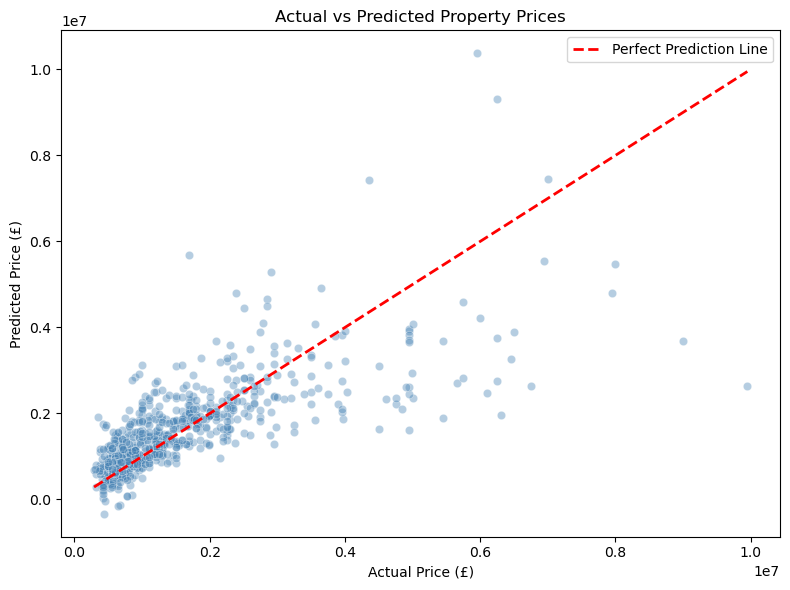

In [24]:
# Plot 1: Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Price (£)')
plt.ylabel('Predicted Price (£)')
plt.title('Actual vs Predicted Property Prices')
plt.legend()
plt.tight_layout()
plt.show()

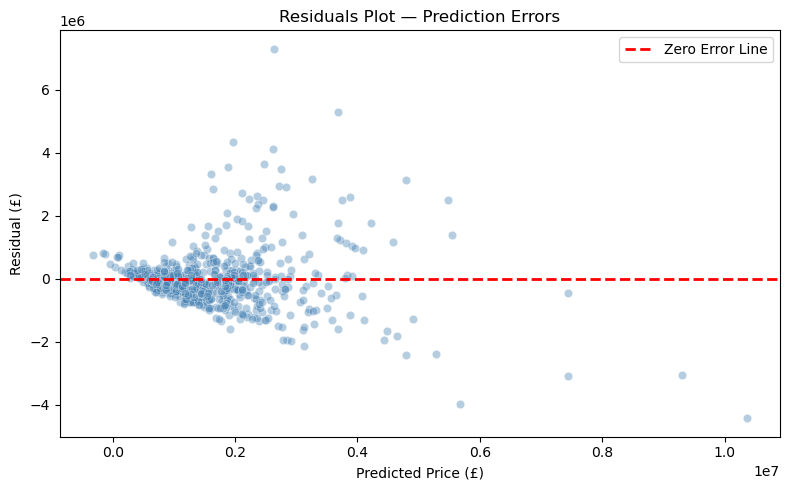

In [25]:
# Plot 2: Residuals Plot
residuals = y_test - y_pred  # prediction errors
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
plt.xlabel('Predicted Price (£)')
plt.ylabel('Residual (£)')
plt.title('Residuals Plot — Prediction Errors')
plt.legend()
plt.tight_layout()
plt.show()

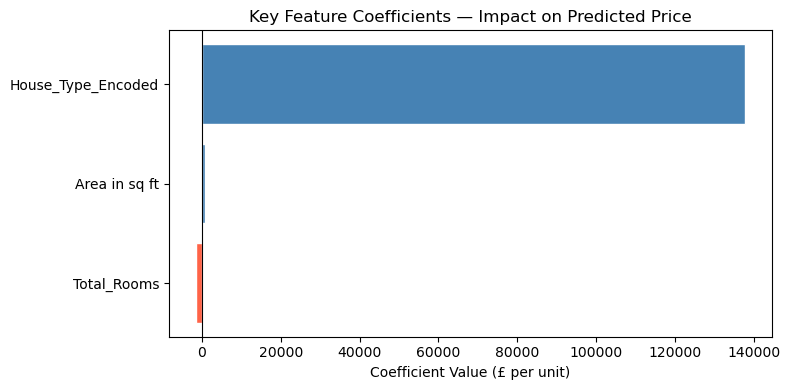

In [26]:
# Plot 3: Key Feature Coefficients (numerical features only)
key_coef = pd.DataFrame({
    'Feature': ['Area in sq ft', 'Total_Rooms', 'House_Type_Encoded'],
    'Coefficient': model.coef_[:3]
}).sort_values('Coefficient')

colors = ['steelblue' if c > 0 else 'tomato' for c in key_coef['Coefficient']]
plt.figure(figsize=(8, 4))
plt.barh(key_coef['Feature'], key_coef['Coefficient'], color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value (£ per unit)')
plt.title('Key Feature Coefficients — Impact on Predicted Price')
plt.tight_layout()
plt.show()

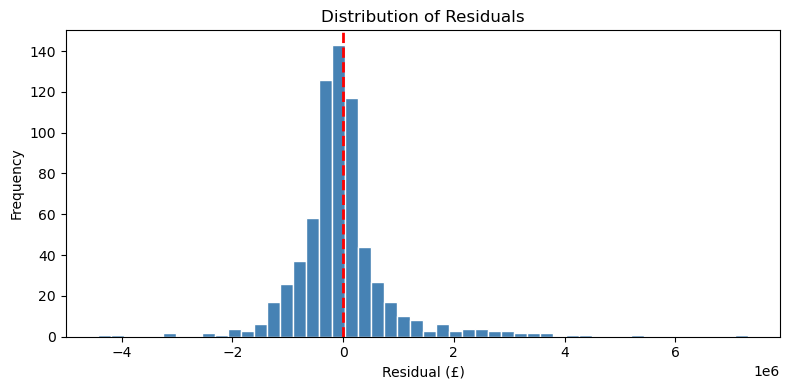

In [27]:
# Plot 4: Distribution of Residuals
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residual (£)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

---
## Section 10: Business Problem Analysis

In [29]:
# Business Problem 1: Price Prediction
# Build sample property with all required features
area_cols_dict = {col: 0.0 for col in ohe_cols.columns}  # default all area dummies to 0
if 'Area_SW15' in area_cols_dict:
    area_cols_dict['Area_SW15'] = 1.0  # set SW15 (Putney area) to 1

sample = pd.DataFrame([{
    'Area in sq ft': 1000.0,
    'Total_Rooms': 4.0,
    'House_Type_Encoded': float(le.transform(['Flat / Apartment'])[0]),
    **area_cols_dict
}])

predicted = model.predict(sample)[0]
print('=== Business Problem 1: Price Prediction ===')
print('Input: 1,000 sq ft Flat, 4 total rooms, SW15 (Putney)')
print(f'Predicted Price: £{round(predicted, 0):,.0f}')

=== Business Problem 1: Price Prediction ===
Input: 1,000 sq ft Flat, 4 total rooms, SW15 (Putney)
Predicted Price: £599,944


In [30]:
# Business Problem 2: Key Factors That Drive Price
print('=== Business Problem 2: Key Price-Driving Factors ===')
for feature, coef in sorted(zip(['Area in sq ft','Total_Rooms','House_Type_Encoded'], model.coef_[:3]),
                             key=lambda x: abs(x[1]), reverse=True):
    direction = '+' if coef > 0 else '-'
    print(f'  {feature}: {direction}£{abs(round(coef,0)):,.0f} per unit')
print('\nLocation (Area Code) also significantly affects price — included via One-Hot Encoding.')

=== Business Problem 2: Key Price-Driving Factors ===
  House_Type_Encoded: +£137,622 per unit
  Total_Rooms: -£1,399 per unit
  Area in sq ft: +£825 per unit

Location (Area Code) also significantly affects price — included via One-Hot Encoding.


In [31]:
# Business Problem 3: Outlier Impact
avg_all    = df['Price'].mean()
avg_normal = df[df['Price_Outlier'] == 'No']['Price'].mean()
avg_outlier = df[df['Price_Outlier'] == 'Yes']['Price'].mean()

print('=== Business Problem 3: Outlier Impact ===')
print(f'Average price (all):           £{round(avg_all, 0):,.0f}')
print(f'Average price (standard):      £{round(avg_normal, 0):,.0f}')
print(f'Average price (outliers only): £{round(avg_outlier, 0):,.0f}')
print(f'Outliers inflate average by:   £{round(avg_all - avg_normal, 0):,.0f}')

=== Business Problem 3: Outlier Impact ===
Average price (all):           £1,867,604
Average price (standard):      £1,700,424
Average price (outliers only): £16,944,605
Outliers inflate average by:   £167,180


---
## Section 11: Reflection

### Connection to Coursework 1
In Coursework 1, Multiple Linear Regression was proposed to address three business problems for UrbanNest Analytics. In this coursework, that proposal has been fully implemented and evaluated. All three business problems have been addressed.

### Addressing CW1 Feedback
The CW1 feedback noted that the Location column contains inconsistent data (district names vs street addresses). In this coursework, this was resolved by:
1. Extracting the **Area Code prefix from Postal Code** (e.g. 'SW15 1PL' → 'SW15')
2. Applying **One-Hot Encoding** on the top 20 most frequent area codes

This approach directly addresses the feedback and improved R² from 0.4272 (no location) to **0.5277** (with One-Hot Area Code).

### Model Performance
The final model achieved **R² = 0.5277** on the test set, explaining approximately 53% of price variance. All key numerical features are statistically significant (p < 0.05). The OLS model on the full dataset achieved R² = 0.56.

### Limitations
- Label Encoding for House Type may introduce unintended ordinal relationships
- Linear Regression assumes linearity, which may not fully capture complex pricing patterns
- The dataset contains listing prices, not actual sale prices
- Some property types (e.g. Mews, Duplex) have very few records

### Potential Improvements
- Apply One-Hot Encoding for House Type as well for better representation
- Try Random Forest or Gradient Boosting Regression for higher R²
- Collect additional features such as proximity to tube stations and school ratings
- Use k-fold cross-validation for more robust evaluation

### Deployment
This model could be deployed as a web-based property valuation tool where estate agents input property details (area, rooms, property type, postal area) and receive an instant price estimate. The model could be retrained quarterly as new listing data becomes available, keeping predictions current with market conditions.